## Table of Contents
0. [Setup](#setup)
1. [Import and Preprocessing](#import-and-preprocessing)
2. [Add Columns](#add-columns)
3. [Extract Features](#extract-features)
4. [Plot Results](#plot-results)
5. [Export](#export)

### Setup

Load PyDPEET and set logging style to "Error" to prevent log spamming.

In [ ]:
import pydpeet as eet

eet.set_logging_style("ERROR")

### Import and Preprocessing
- Import example data
    - Test device: Neware
    - 4 checkups (capacity test, GITT)
    - Calendar ageing
- Merge the 4 files into one DataFrame for easier processing
- Add primitive segments, like "CC","CV" or "Rest" to the DataFrame and saving in an extra variable

In [2]:
dfs = eet.read(config="neware_8_0_0_516", input_path="../../../res/raw")
df_merged = eet.merge_into_series(dfs)
df_segments = eet.add_primitive_segments(df_merged)

### Add Columns
- Loading the configuration of the used cell (LGM50LT with 4.8 Ah)
- Adding SOC to the DataFrame
- Adding internal resistance to the DataFrame
- Adding the charge throughput to the DataFrame

In [3]:
config = eet.lgm50lt_nmc_4800
df_merged = eet.add_soc(df_merged, df_segments, standard_method=eet.SocMethod.WITH_RESET_WHEN_FULL, config=config)
df_merged = eet.add_resistance_internal(df_merged, config=config)
df_merged = eet.process.analyze.capacity.add_charge_throughput(df_merged)

### Extract Features
- Extract iOCV

In [4]:
ocv_data = eet.extract_ocv_iocv(df=df_merged, config=eet.lgm50lt_nmc_4800, visualize=False)

### Plot Results 

- Plotting the results using Matplotlib

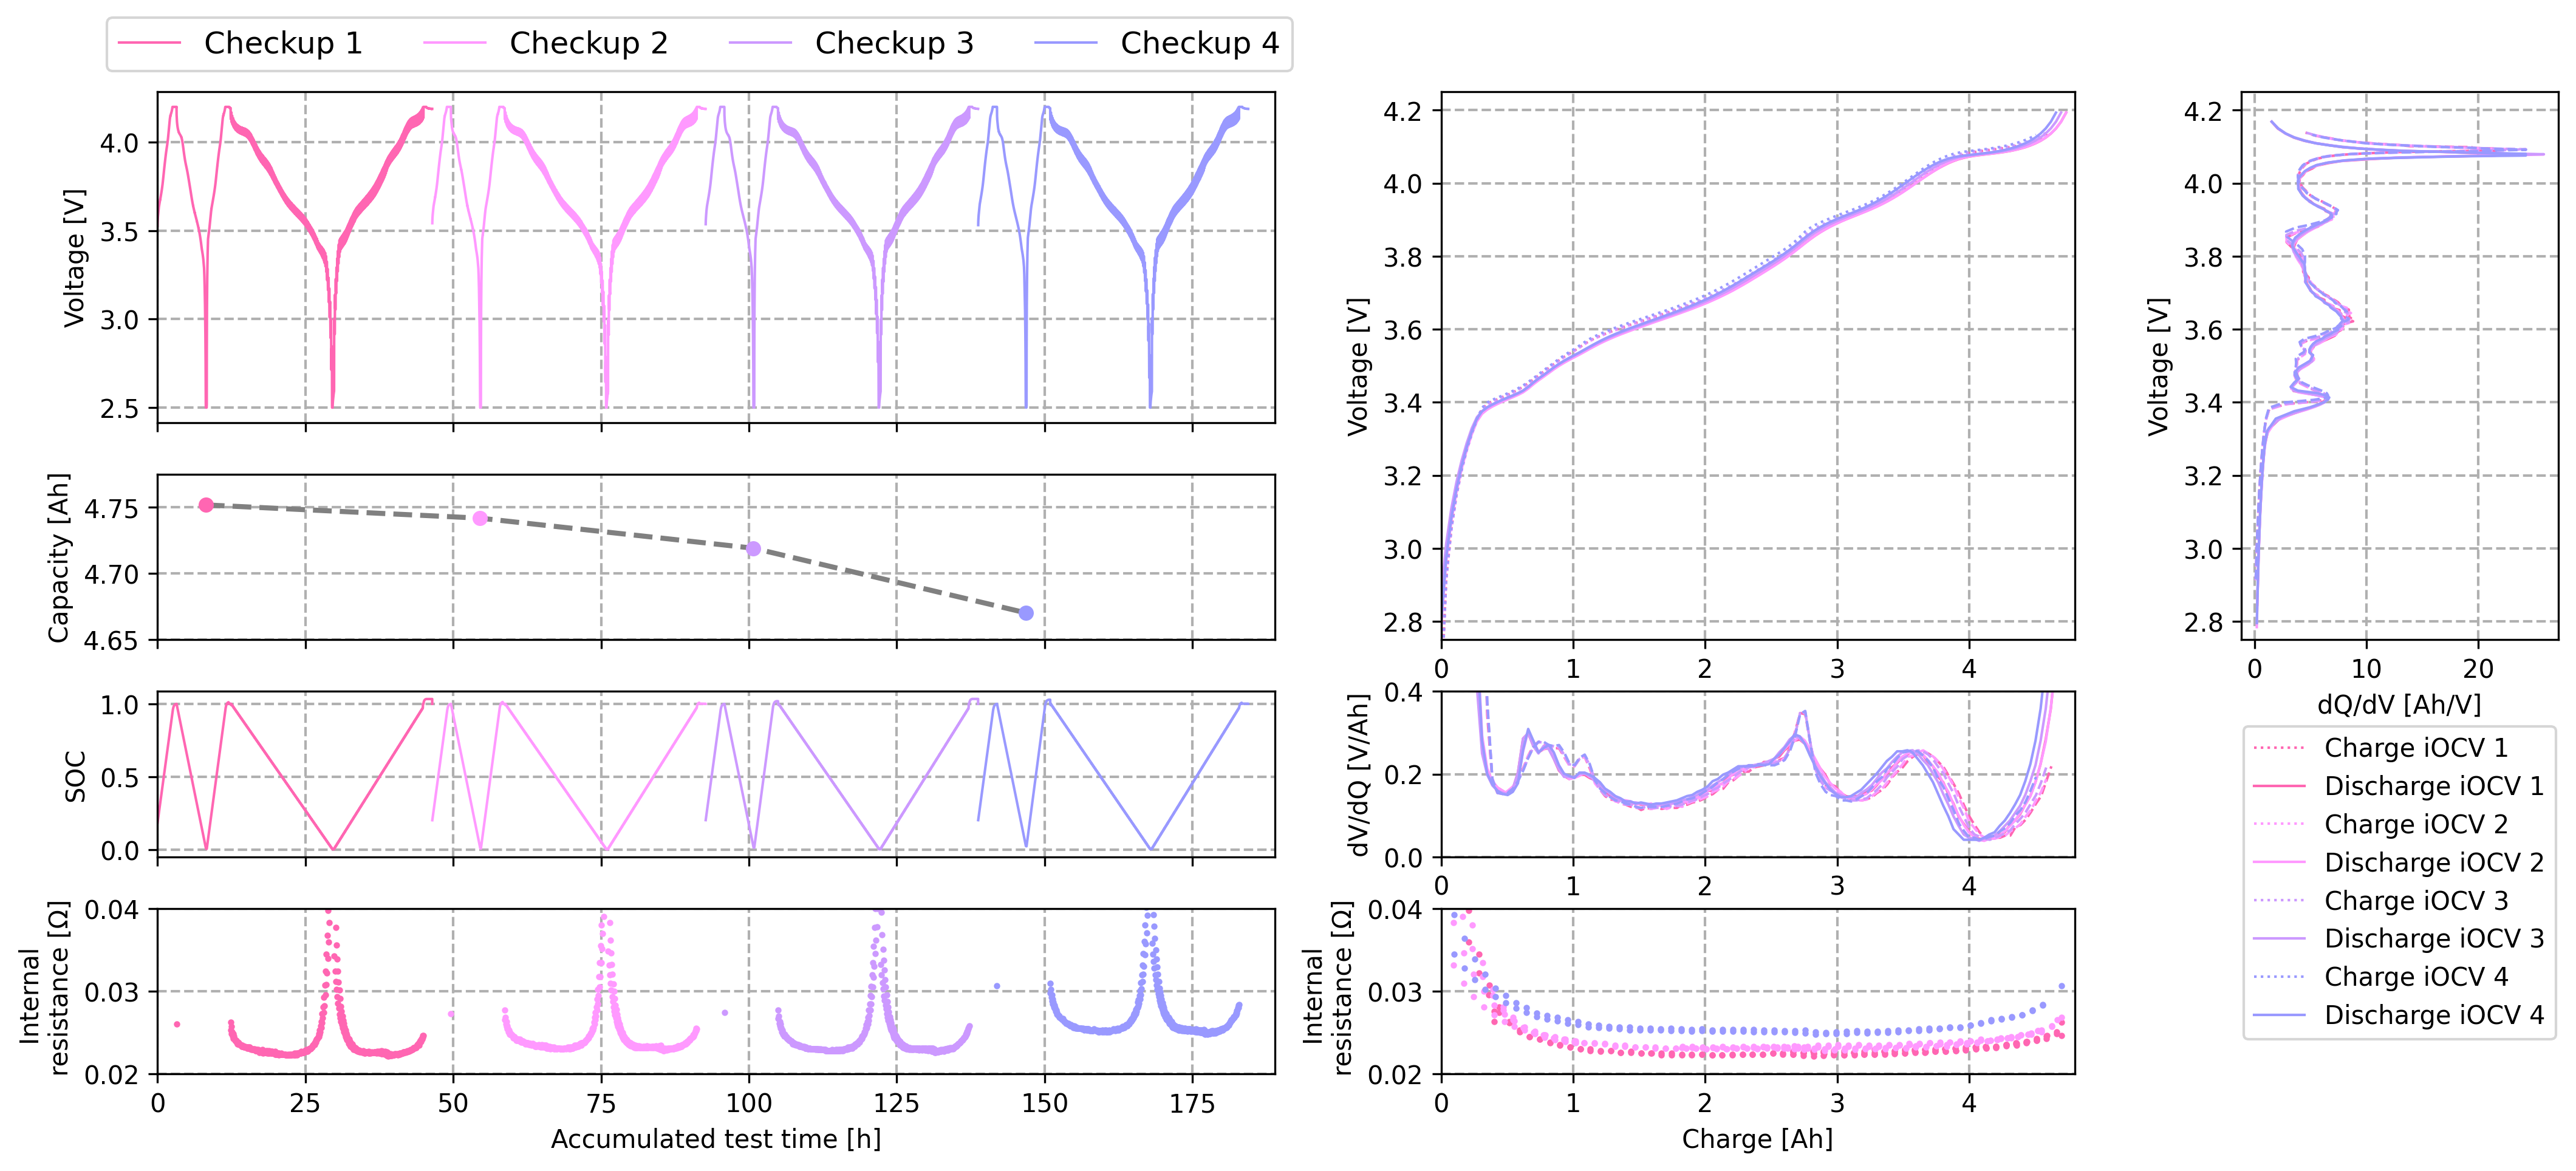

In [ ]:
from plot_helper import KWB_plot  # noqa

KWB_plot(df_merged, ocv_data)

# Export

Export data frame to Parquet file.

In [6]:
eet.write(df_merged, output_path="./parquet", output_file_name="Test_Output")